# DX 601 Final Project

## Introduction

In this project, you will practice all the skills that you have learned throughout this module.
You will pick a data set to analyze from a list provided, and then perform a variety of analysis.
Most of the problems and questions are open ended compared to your previous homeworks, and you will be asked to explain your choices.
Most of them will have a particular type of solution implied, but it is up to you to figure out the details based on what you have learned in this module.

## Instructions

Each problem asks you to perform some analysis of the data, and usually answer some questions about the results.
Make sure that your question answers are well supported by your analysis and explanations; simply stating an answer without support will earn minimal points.

Notebook cells for code and text have been added for your convenience, but feel free to add additional cells.

## Example Code

You may find it helpful to refer to this GitHub repository of Jupyter notebooks for example code.

* https://github.com/bu-cds-omds/dx500-examples
* https://github.com/bu-cds-omds/dx601-examples
* https://github.com/bu-cds-omds/dx602-examples

Any calculations demonstrated in code examples or videos may be found in these notebooks, and you are allowed to copy this example code in your homework answers.

## Submission

This project will be entirely manually graded.
However, we may rerun some or all of your code to confirm that it works as described.

### Late Policy

The normal homework late policy for OMDS does not apply to this project.
Boston University requires final grades to be submitted within 72 hours of class instruction ending, so we cannot accommodate 5 days of late submissions.

However, we have delayed the due date of this project to be substantially later than necessary given its scope, and given you more days for submission with full credit than you would have had days for submission with partial credit under the homework late policy.
Finally, the deadlines for DX 601 and DX 602 were coordinated to be a week apart while giving ample time for both of their projects.

## Shared Imports

For this project, you are forbidden to use modules that were not loaded in this template.
While other modules are handy in practice, modules that trivialize these problems interfere with our assessment of your own knowledge and skills.

If you believe a module covered in the course material (not live sessions) is missing, please check with your learning facilitator.

In [2]:
import math
import sys

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats
import sklearn.linear_model

from sklearn.decomposition import PCA

## Problems

### Problem 1 (5 points)

Pick one of the following data sets to analyze in this project.
Load the data set, and show a random sample of 10 rows.

* [Iris data set](https://archive.ics.uci.edu/dataset/53/iris) ([PMLB copy](https://github.com/EpistasisLab/pmlb/tree/master/datasets/iris))
* [Breast Cancer Wisconsin](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic) ([PMLB copy](https://github.com/EpistasisLab/pmlb/tree/master/datasets/_deprecated_breast_cancer_wisconsin))
* [Wine Quality](https://archive.ics.uci.edu/dataset/186/wine+quality) ([PMLB - white subset only](https://github.com/EpistasisLab/pmlb/tree/master/datasets/wine_quality_white))


The PMLB copies of the data are generally cleaner and recommended for this project, but the other links are provided to give you more context.
To load the data from the PMLB Github repository, navigate to the `.tsv.gz` file in GitHub and copy the link from the "Raw" button.

If the data set you choose has more than ten columns, you may limit later analysis that is requested per column to just the first ten columns.

In [4]:
# reads the tsv file and assigns it to a variable name, separating the columns by tab
wine_quality_white = pd.read_csv('wine_quality_white.tsv', sep='\t')

# loads the data set and shows a random sample of 10 rows
wine_quality_white.sample(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,target
666,6.8,0.22,0.37,1.7,0.036,38.0,195.0,0.99080,3.35,0.72,12.5,6
4583,6.4,0.23,0.37,7.9,0.050,60.0,150.0,0.99488,2.86,0.49,9.3,6
3419,6.1,0.30,0.30,2.1,0.031,50.0,163.0,0.98950,3.39,0.43,12.7,7
3683,6.8,0.15,0.41,12.9,0.044,79.5,183.0,0.99742,3.24,0.78,10.2,6
334,5.6,0.26,0.26,5.7,0.031,12.0,80.0,0.99230,3.25,0.38,10.8,5
4783,6.7,0.30,0.50,12.1,0.045,38.0,127.0,0.99740,3.04,0.53,8.9,6
2119,8.0,0.16,0.36,1.5,0.033,14.0,122.0,0.99410,3.20,0.39,10.3,4
1947,5.7,0.45,0.42,1.1,0.051,61.0,197.0,0.99320,3.02,0.40,9.0,5
3402,7.7,0.46,0.18,3.3,0.054,18.0,143.0,0.99392,3.12,0.51,10.8,6
3761,6.1,0.17,0.28,2.5,0.028,22.0,98.0,0.99072,3.16,0.37,11.1,7


For this project, I'll be analyzing the Wine Quality data set. The first 10 rows of the data are visible above.

### Problem 2 (10 points)

List all the columns in the data set, and describe each of them in your own words.
You may have to search to learn about the data set columns, but make sure that the descriptions are your own words.

In [77]:
wine_quality_white.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'target'],
      dtype='object')

In the data set, there are 12 columns. They are the following: 
- fixed acidity: The acid that is in wine that gives the wine a tart and crisp taste.
- volatile acidity: The acid that smells sharp. Too much of this acid and the wine can smell like vinegar.
- citric acid: A citrus-like acid that adds freshness to the wine.
- residual sugar: This is the leftover sugar after the wine is fermented.
- chlorides: This is the salt levels of the wine.
- free sulfur dioxide: This protects the wine from spoiling.
- total sulfur dioxide: This is the total amount of all of the sulfur dioxide in the wine.
- density: How "heavy" the wine is compared to water.
- pH: How strong the wine's acidity is.
- sulphates: These help to perserve the wine.
- alcohol: The percentage of ethanol, affecting the wine's warmth, body, and flavor.
- target: The quality of the wine, a score of 1-10.

### Problem 3 (15 points)

Plot histograms of each column.
For each column, state the distribution covered in this module that you think best matches that column.

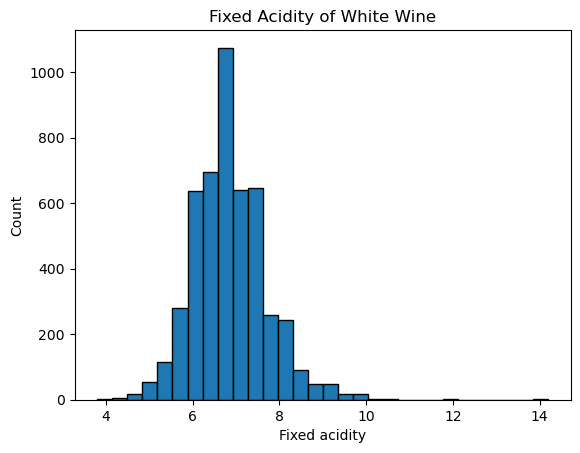

In [65]:
# fixed acidity histogram
plt.hist(wine_quality_white["fixed acidity"], edgecolor="black", bins=30)
plt.title("Fixed Acidity of White Wine")
plt.xlabel("Fixed acidity")
plt.ylabel("Count")
plt.show()


The fixed acidity histogram has a right-skewed distribution.

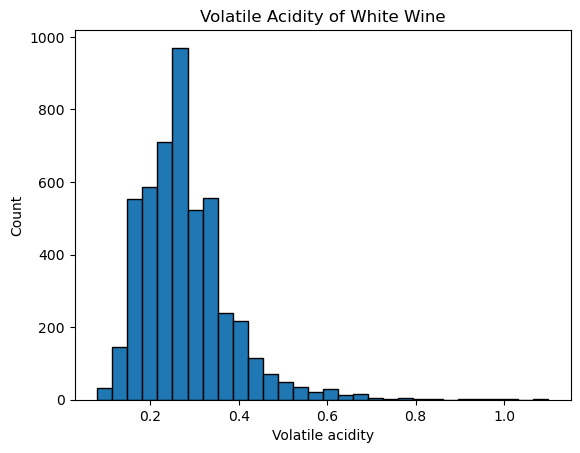

In [66]:
# volatile acidity histogram
plt.hist(wine_quality_white["volatile acidity"], edgecolor="black", bins=30)
plt.title("Volatile Acidity of White Wine")
plt.xlabel("Volatile acidity")
plt.ylabel("Count")
plt.show()

The volatile acidity histogram has a right-skewed distribution.

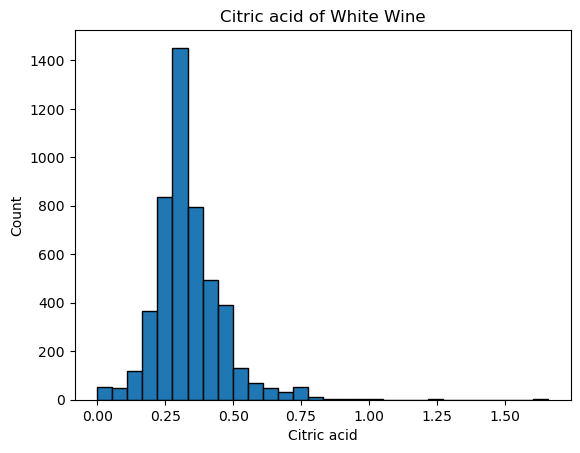

In [67]:
# citric acid histogram
plt.hist(wine_quality_white["citric acid"], edgecolor="black", bins=30)
plt.title("Citric acid of White Wine")
plt.xlabel("Citric acid")
plt.ylabel("Count")
plt.show()

The cirtic acid histogram has a right-skewed distribution.

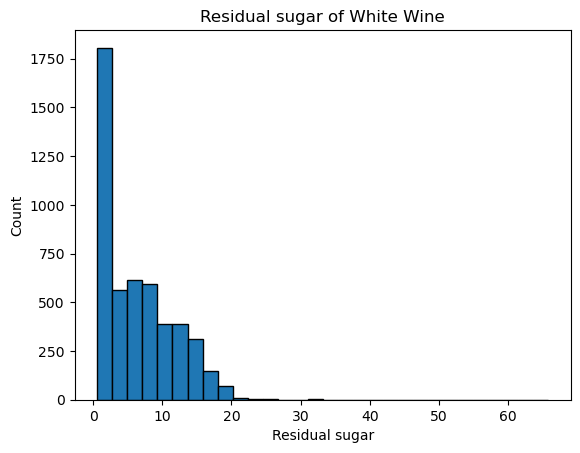

In [68]:
# residual sugar histogram
plt.hist(wine_quality_white["residual sugar"], edgecolor="black", bins=30)
plt.title("Residual sugar of White Wine")
plt.xlabel("Residual sugar")
plt.ylabel("Count")
plt.show()

The residual sugar histogram has a right-skewed distribution.

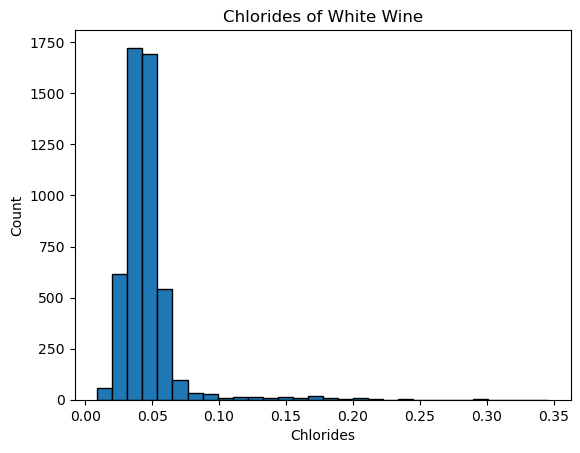

In [69]:
# chlorides histogram
plt.hist(wine_quality_white["chlorides"], edgecolor="black", bins=30)
plt.title("Chlorides of White Wine")
plt.xlabel("Chlorides")
plt.ylabel("Count")
plt.show()

The chlorides histogram has a right-skewed distribution.

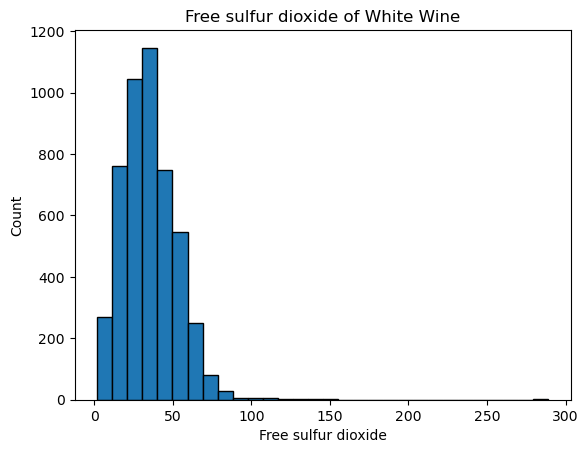

In [70]:
# free sulfur dioxide histogram
plt.hist(wine_quality_white["free sulfur dioxide"], edgecolor="black", bins=30)
plt.title("Free sulfur dioxide of White Wine")
plt.xlabel("Free sulfur dioxide")
plt.ylabel("Count")
plt.show()

The free sulfur dioxide histogram has a right-skewed distribution.

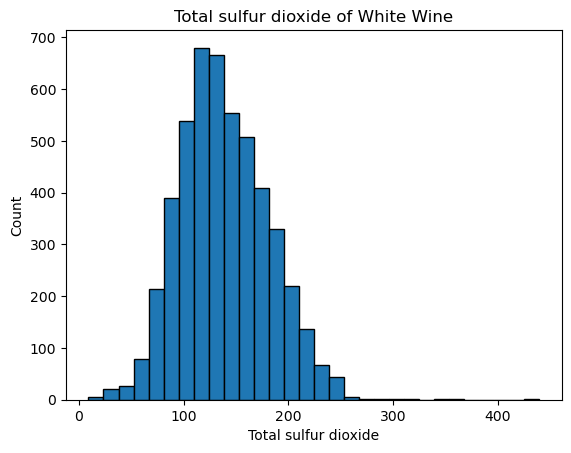

In [71]:
# total sulfur dioxide histogram
plt.hist(wine_quality_white["total sulfur dioxide"], edgecolor="black", bins=30)
plt.title("Total sulfur dioxide of White Wine")
plt.xlabel("Total sulfur dioxide")
plt.ylabel("Count")
plt.show()

The total sulfur dioxide histogram has a right-skewed distribution.

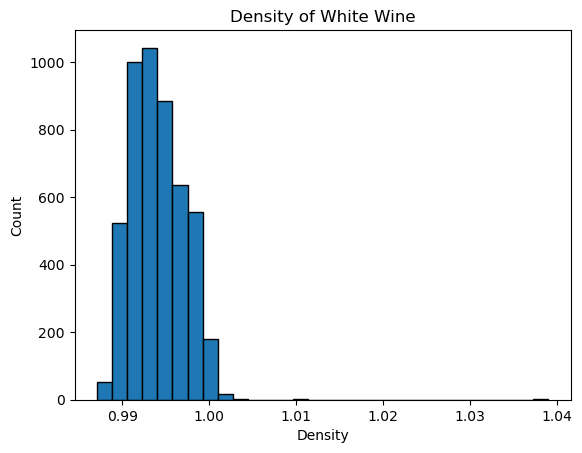

In [72]:
# density histogram
plt.hist(wine_quality_white["density"], edgecolor="black", bins=30)
plt.title("Density of White Wine")
plt.xlabel("Density")
plt.ylabel("Count")
plt.show()

The density histogram has a right-skewed distribution.

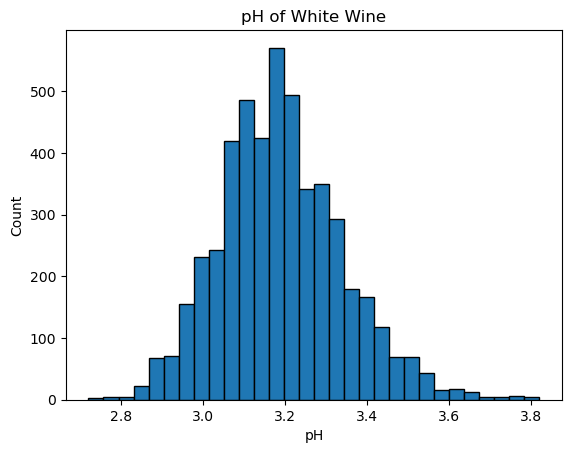

In [73]:
# pH histogram
plt.hist(wine_quality_white["pH"], edgecolor="black", bins=30)
plt.title("pH of White Wine")
plt.xlabel("pH")
plt.ylabel("Count")
plt.show()

The pH histogram is bell shaped and has a nearly normal distribution.

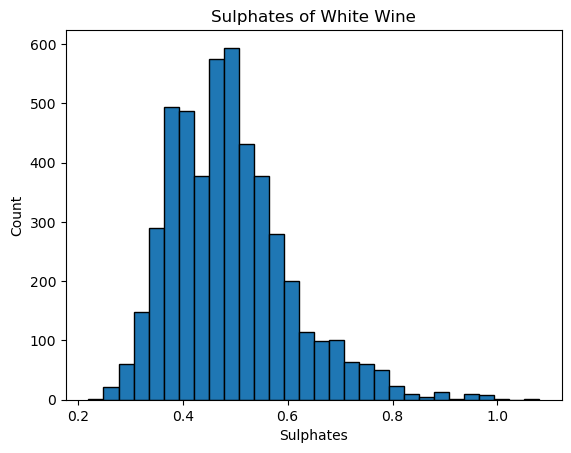

In [74]:
# sulphates histogram
plt.hist(wine_quality_white["sulphates"], edgecolor="black", bins=30)
plt.title("Sulphates of White Wine")
plt.xlabel("Sulphates")
plt.ylabel("Count")
plt.show()

The sulphates histogram has a right-skewed distribution.

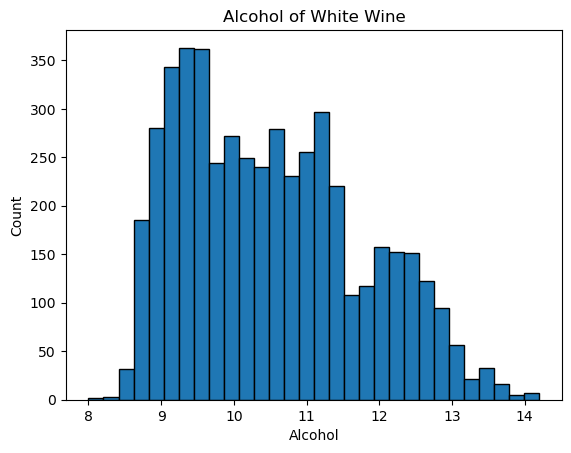

In [75]:
# alcohol histogram
plt.hist(wine_quality_white["alcohol"], edgecolor="black", bins=30)
plt.title("Alcohol of White Wine")
plt.xlabel("Alcohol")
plt.ylabel("Count")
plt.show()

The alcohol histogram has a right-skewed distribution.

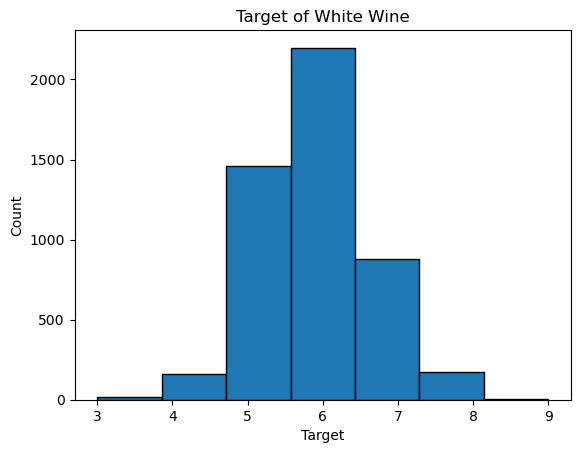

In [76]:
# target histogram
plt.hist(wine_quality_white["target"], edgecolor="black", bins=7)
plt.title("Target of White Wine")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

The target histogram is nearly bell shaped and has a normal distribution.

### Problem 4 (20 points)

Plot each pair of an input column and the output column.
Classify each pair of input column and the output column as being independent or not.
Describe in words why you think that was the case.

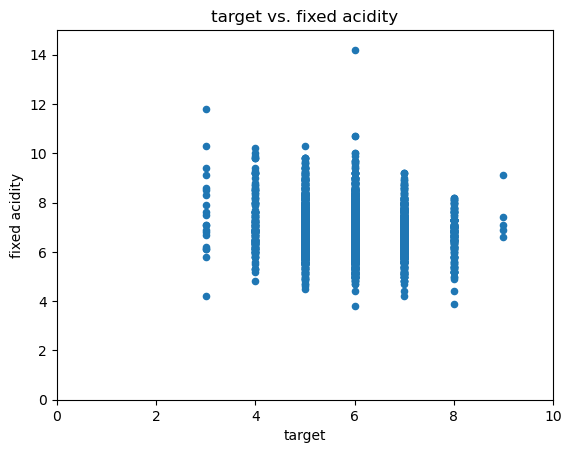

In [86]:
# YOUR CODE HERE
wine_quality_white.plot.scatter("target", "fixed acidity")
plt.xlim(0,10)
plt.ylim(0,15)
plt.title("target vs. fixed acidity")
plt.show()

independent - there is no pattern, scattered vertically with no clear upward or downward trend

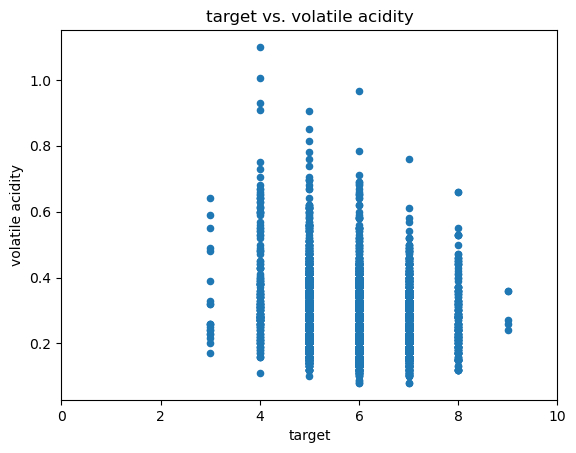

In [89]:
wine_quality_white.plot.scatter("target", "volatile acidity")
plt.xlim(0,10)
plt.title("target vs. volatile acidity")
plt.show()

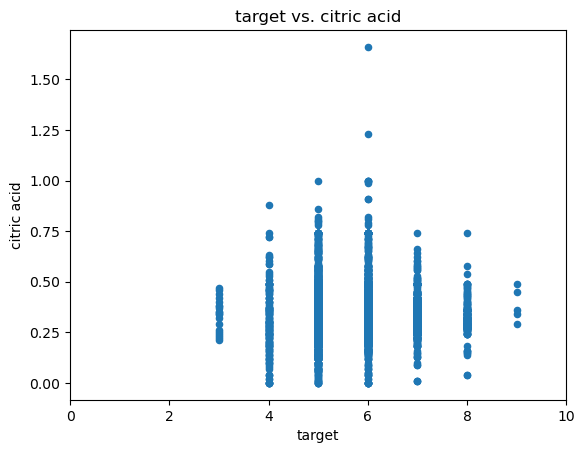

In [90]:
wine_quality_white.plot.scatter("target", "citric acid")
plt.xlim(0,10)
plt.title("target vs. citric acid")
plt.show()

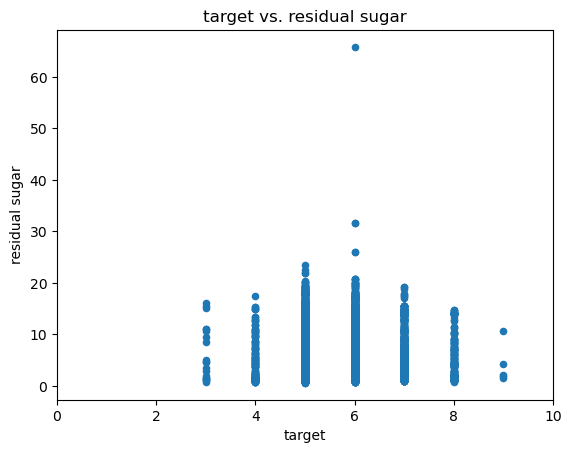

In [91]:
wine_quality_white.plot.scatter("target", "residual sugar")
plt.xlim(0,10)
plt.title("target vs. residual sugar")
plt.show()

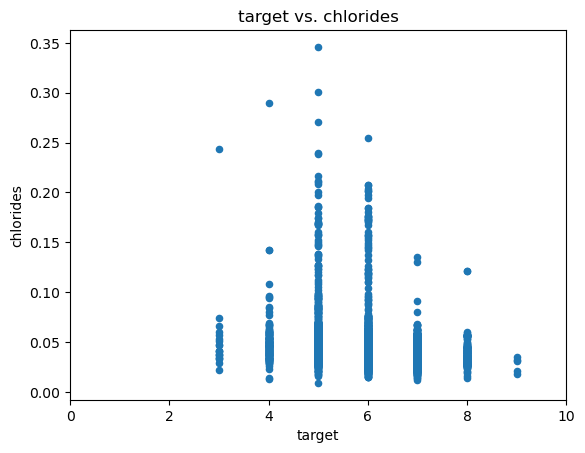

In [92]:
wine_quality_white.plot.scatter("target", "chlorides")
plt.xlim(0,10)
plt.title("target vs. chlorides")
plt.show()

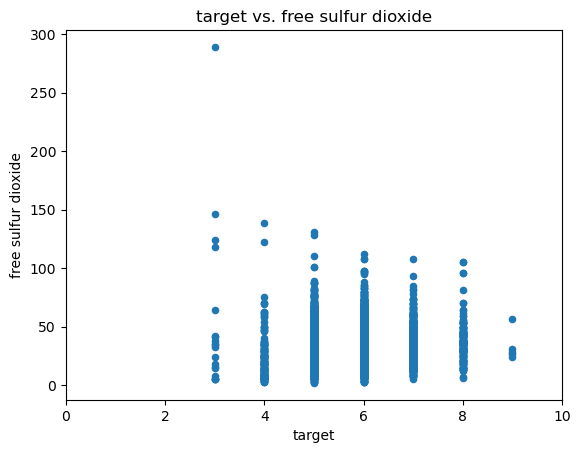

In [93]:
wine_quality_white.plot.scatter("target", "free sulfur dioxide")
plt.xlim(0,10)
plt.title("target vs. free sulfur dioxide")
plt.show()

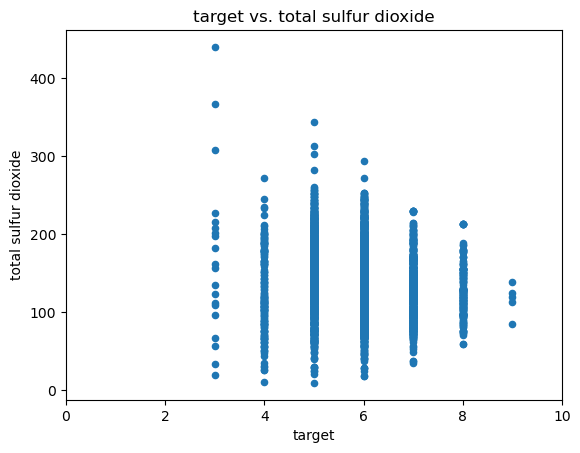

In [94]:
wine_quality_white.plot.scatter("target", "total sulfur dioxide")
plt.xlim(0,10)
plt.title("target vs. total sulfur dioxide")
plt.show()

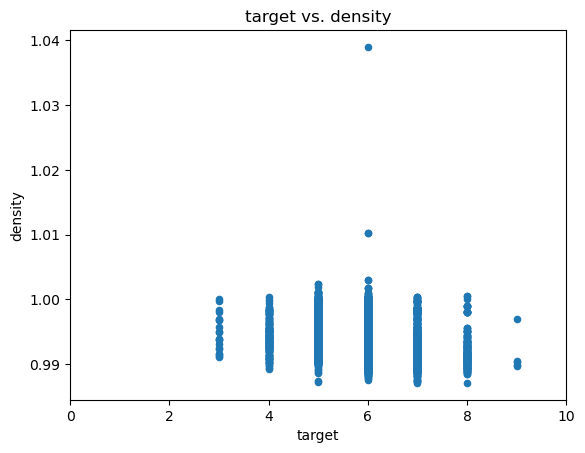

In [95]:
wine_quality_white.plot.scatter("target", "density")
plt.xlim(0,10)
plt.title("target vs. density")
plt.show()

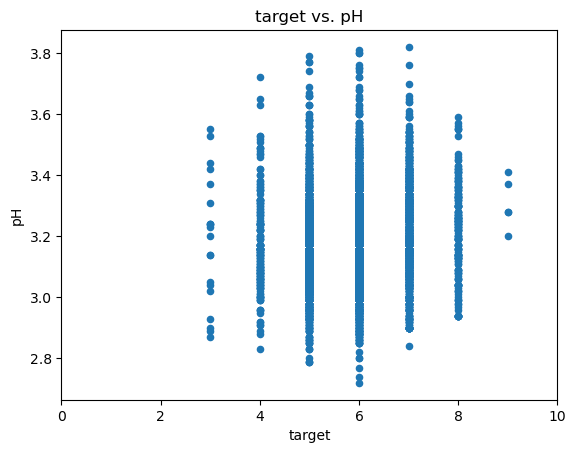

In [96]:
wine_quality_white.plot.scatter("target", "pH")
plt.xlim(0,10)
plt.title("target vs. pH")
plt.show()

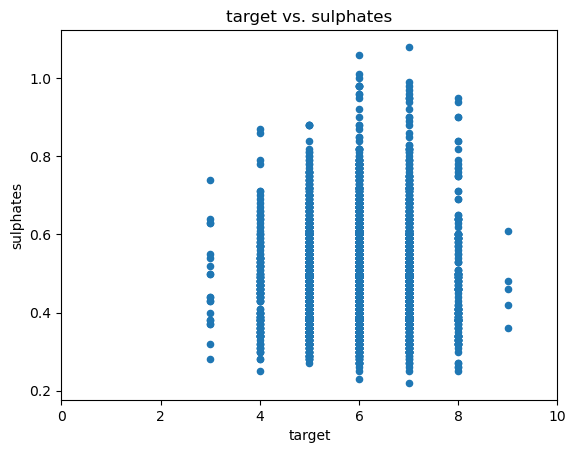

In [97]:
wine_quality_white.plot.scatter("target", "sulphates")
plt.xlim(0,10)
plt.title("target vs. sulphates")
plt.show()

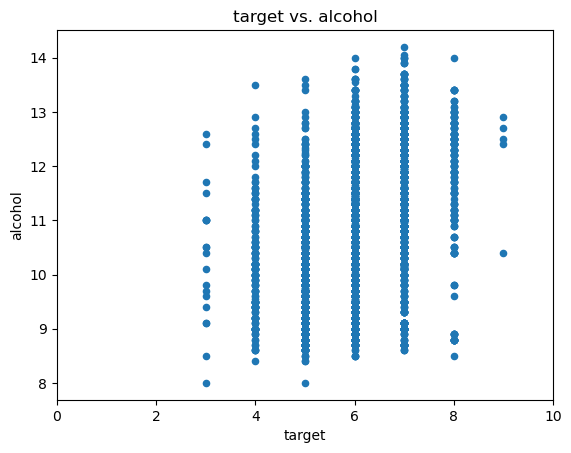

In [107]:
wine_quality_white.plot.scatter("target", "alcohol")
plt.xlim(0,10)
plt.title("target vs. alcohol")
plt.show()

YOUR ANSWERS HERE

### Problem 5 (20 points)

Build an ordinary least squares regression for the target using all the input columns.
Report the mean squared error of the model over the whole data set.
Plot the actual values vs the predicted outputs to compare them. 

In [118]:
# importing Linear Regression
from sklearn.linear_model import LinearRegression
model = LinearRegression()

# drop the target column and keep the other columns for all rows of x
x = wine_quality_white.drop(columns="target")


y = wine_quality_white["target"]

# fit the model using rows of y
model.fit(x, y)

predicted = model.predict(x)


YOUR ANSWERS HERE

### Problem 6 (20 points)

Which input column gives the best linear model of the target on its own?
How does that model compare to the model in problem 5?


In [ ]:
# YOUR CODE HERE

YOUR ANSWERS HERE

### Problem 7 (20 points)

Pick and plot a pair of input columns with a visible dependency.
Identify a split of the values of one column illustrating the dependency and plot histograms of the other variable on both sides of the split.
That is, pick a threshold $t$ for one column $x$ and make two histograms, one where $x < t$ and one where $x \geq t$.

These histograms should look significantly different to make the dependency clear.
There should be enough data in both histograms so that these differences are unlikely to be noise.
Also make sure that the horizontal axis is the same in both histograms for clarity.

In [ ]:
# YOUR CODE HERE

YOUR ANSWERS HERE

### Problem 8 (40 points)

Perform principal components analysis of the input columns.
Compute how much of the data variation is explained by the first half of the principal components.
Build a linear regression using coordinates computed from the first half of the principal components.
Compare the mean squared error of this model to the previous model.
Plot actual targets vs predictions again. 

This problem depends on material from week 13.

In [ ]:
# YOUR CODE HERE

YOUR ANSWERS HERE

### Problem 9 (20 points)

What pair of input columns has the highest correlation?
How is that correlation reflected in the principal components?

In [ ]:
# YOUR CODE HERE

YOUR ANSWERS HERE

### Problem 10 (30 points)

Identify an outlier row in the data set.
You may use any criteria discussed in this module, and you must explain the criteria and how it led to picking this row.
Give a visualization showing how much this row sticks out compared to the other data based on your criteria.

In [ ]:
# YOUR CODE HERE

YOUR ANSWERS HERE

### Generative AI Usage

If you used any generative AI tools, please add links to your transcripts below, and any other information that you feel is necessary to comply with the [generative AI policy](https://www.bu.edu/cds-faculty/culture-community/gaia-policy/).
If you did not use any generative AI tools, simply write NONE below.

YOUR ANSWER HERE